In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
import matplotlib.pyplot as plt


In [2]:
class DynamicEnv(gym.Env):
    def __init__(self):
        super(DynamicEnv, self).__init__()
        self.observation_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.action_space = spaces.Discrete(3)  # left, stay, right
        self.state = 0.0
        self.noise = 0.05

    def step(self, action):
        change = (action - 1) * 0.1
        self.state += change + np.random.normal(0, self.noise)
        reward = -abs(self.state)
        self.noise = min(0.3, self.noise + 0.001)  # dynamic increase in noise
        done = abs(self.state) > 1
        return np.array([self.state], dtype=np.float32), reward, done, False, {}

    def reset(self, seed=None):
        super().reset(seed=seed)
        self.state = np.random.uniform(-0.2, 0.2)
        self.noise = 0.05
        return np.array([self.state], dtype=np.float32), {}


In [3]:
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return self.net(x)


In [4]:
env = DynamicEnv()
agent = DQN(1, 3)
optimizer = optim.Adam(agent.parameters(), lr=0.001)
criterion = nn.MSELoss()

def train_agent(episodes=300):
    rewards = []
    for ep in range(episodes):
        state, _ = env.reset()
        total_reward = 0
        for t in range(200):
            s = torch.FloatTensor(state)
            q_values = agent(s)
            action = torch.argmax(q_values).item() if random.random() > 0.1 else random.choice([0,1,2])
            next_state, reward, done, _, _ = env.step(action)

            target = reward + 0.95 * torch.max(agent(torch.FloatTensor(next_state))).item()
            loss = criterion(q_values[action], torch.tensor(target))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_reward += reward
            state = next_state
            if done:
                break
        rewards.append(total_reward)
    return rewards


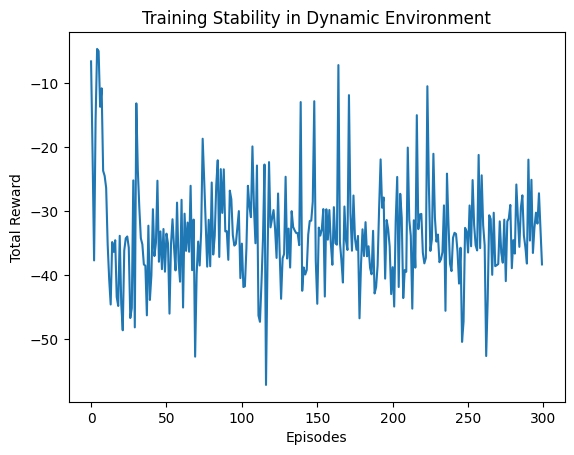

In [5]:
results = train_agent(300)
plt.plot(results)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Training Stability in Dynamic Environment")
plt.show()
